**Netflix Content Strategy Analyzer: Insights into Global Streaming Trends**

In [73]:
import pandas as pd
import kagglehub
import matplotlib as plt


In [74]:
# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [75]:
df = pd.read_csv("/kaggle/input/netflix-shows/netflix_titles.csv")

In [76]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [77]:
df.shape

(8807, 12)

In [78]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [79]:

df[df.duplicated()].sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [80]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


# **Data cleaning**

# Handling null, missing and inconsistent categories

In [81]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

In [82]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,10
release_year,0
rating,4
duration,3


In [83]:
df = df.dropna(subset=['rating'])
df = df.dropna(subset=['duration'])
df = df.dropna(subset=['date_added'])

In [84]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


**Handle Inconsistent Columns**

In [85]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['release_year'] = pd.to_numeric(df['release_year'], errors='coerce')



In [86]:
df['date_added'].dtype

dtype('<M8[ns]')

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   show_id       8790 non-null   object        
 1   type          8790 non-null   object        
 2   title         8790 non-null   object        
 3   director      8790 non-null   object        
 4   cast          8790 non-null   object        
 5   country       8790 non-null   object        
 6   date_added    8702 non-null   datetime64[ns]
 7   release_year  8790 non-null   int64         
 8   rating        8790 non-null   object        
 9   duration      8790 non-null   object        
 10  listed_in     8790 non-null   object        
 11  description   8790 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(10)
memory usage: 892.7+ KB


In [88]:
df=df.rename(columns={"listed_in":"genre"})

In [89]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# **NORMALIZATION**

In [90]:
df['genre'].unique()

array(['Documentaries', 'International TV Shows, TV Dramas, TV Mysteries',
       'Crime TV Shows, International TV Shows, TV Action & Adventure',
       'Docuseries, Reality TV',
       'International TV Shows, Romantic TV Shows, TV Comedies',
       'TV Dramas, TV Horror, TV Mysteries', 'Children & Family Movies',
       'Dramas, Independent Movies, International Movies',
       'British TV Shows, Reality TV', 'Comedies, Dramas',
       'Crime TV Shows, Docuseries, International TV Shows',
       'Dramas, International Movies',
       'Children & Family Movies, Comedies',
       'British TV Shows, Crime TV Shows, Docuseries',
       'TV Comedies, TV Dramas', 'Documentaries, International Movies',
       'Crime TV Shows, Spanish-Language TV Shows, TV Dramas',
       'Thrillers',
       'International TV Shows, Spanish-Language TV Shows, TV Action & Adventure',
       'International TV Shows, TV Action & Adventure, TV Dramas',
       'Comedies, International Movies',
       'Comedies, 

In [91]:
df['genre'] = df['genre'].str.split(',')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,[Documentaries],"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, TV Dramas, TV Myste...","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"[Crime TV Shows, International TV Shows, TV ...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"[Docuseries, Reality TV]","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"[International TV Shows, Romantic TV Shows, ...",In a city of coaching centers known to train I...


In [92]:

df = df.explode('genre')
df['genre'] = df['genre'].str.strip()
df['genre'] = df['genre'].str.title()

In [93]:
#remove any leading or trailing spaces
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [94]:
#to lower case
df = df.apply(lambda x: x.str.lower() if x.dtype == "object" else x)

In [95]:
df['duration_minutes'] = df['duration'].where(df['type'] == 'movie')
df['seasons'] = df['duration'].where(df['type'] == 'tv show')


In [96]:
df['seasons'] = df['seasons'].str.extract(r'(\d+)').astype(float)
df['duration_minutes'] = df['duration_minutes'].str.extract(r'(\d+)').astype(float)

In [97]:
df['date_added'] = df['date_added'].fillna('Unknown')
df['seasons'] = df['seasons'].fillna('Unknown')
df['duration_minutes'] = df['duration_minutes'].fillna('Unknown')

In [98]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,duration_minutes,seasons
0,s1,movie,dick johnson is dead,kirsten johnson,unknown,united states,2021-09-25 00:00:00,2020,pg-13,90 min,documentaries,"as her father nears the end of his life, filmm...",90.0,Unknown
1,s2,tv show,blood & water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",south africa,2021-09-24 00:00:00,2021,tv-ma,2 seasons,international tv shows,"after crossing paths at a party, a cape town t...",Unknown,2.0
1,s2,tv show,blood & water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",south africa,2021-09-24 00:00:00,2021,tv-ma,2 seasons,tv dramas,"after crossing paths at a party, a cape town t...",Unknown,2.0
1,s2,tv show,blood & water,unknown,"ama qamata, khosi ngema, gail mabalane, thaban...",south africa,2021-09-24 00:00:00,2021,tv-ma,2 seasons,tv mysteries,"after crossing paths at a party, a cape town t...",Unknown,2.0
2,s3,tv show,ganglands,julien leclercq,"sami bouajila, tracy gotoas, samuel jouy, nabi...",unknown,2021-09-24 00:00:00,2021,tv-ma,1 season,crime tv shows,to protect his family from a powerful drug lor...,Unknown,1.0


In [99]:
df = df.dropna(subset=['genre'])
df = df.reset_index(drop=True)


# Analyze Netflix content growth over time.

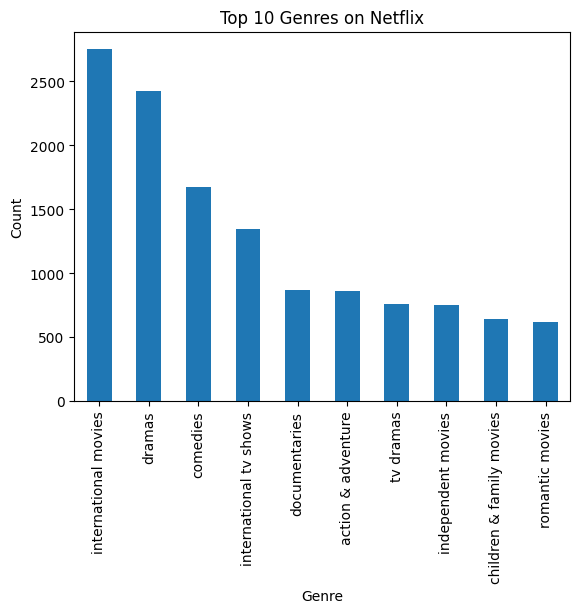

In [100]:
import matplotlib.pyplot as plt

genre = df['genre'].str.split(',', expand=True).stack().str.strip()

genre.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

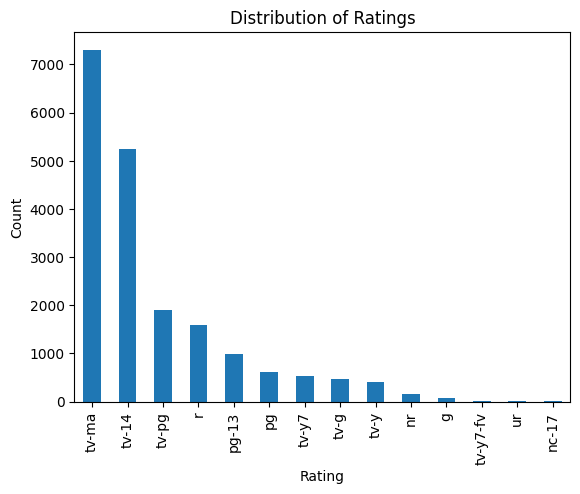

In [101]:
df['rating'].value_counts().plot(kind='bar')

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [102]:
df['country'].str.contains(',').sum()

np.int64(2874)

In [103]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


<Axes: title={'center': 'Netflix Content Growth Over Time'}, xlabel='year_added'>

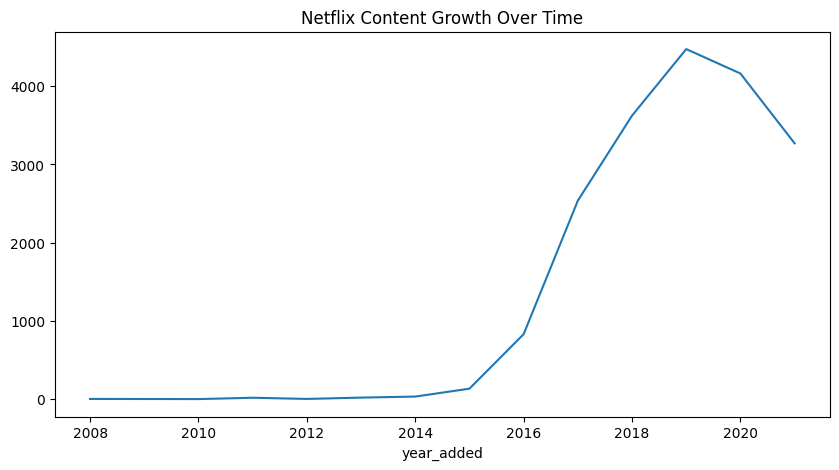

In [104]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df['year_added'] = df['date_added'].dt.year
content_growth = df.groupby('year_added')['show_id'].count()

content_growth.plot(kind='line', figsize=(10,5), title="Netflix Content Growth Over Time")

<Axes: title={'center': 'Distribution of Content Type'}, xlabel='type'>

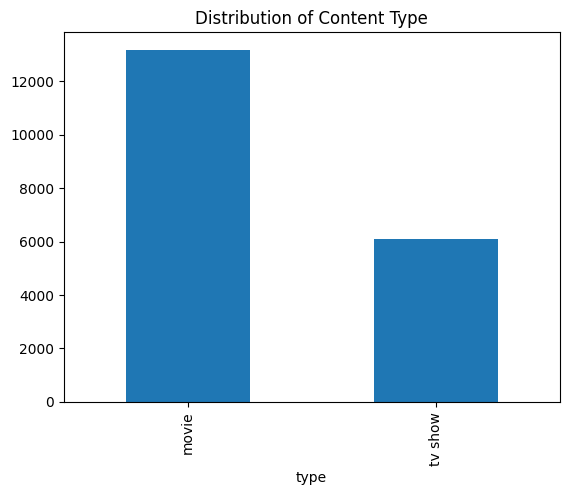

In [105]:
df['type'].value_counts().plot(kind='bar', title='Distribution of Content Type')

<Axes: title={'center': 'Top Content Producing Countries'}, xlabel='country'>

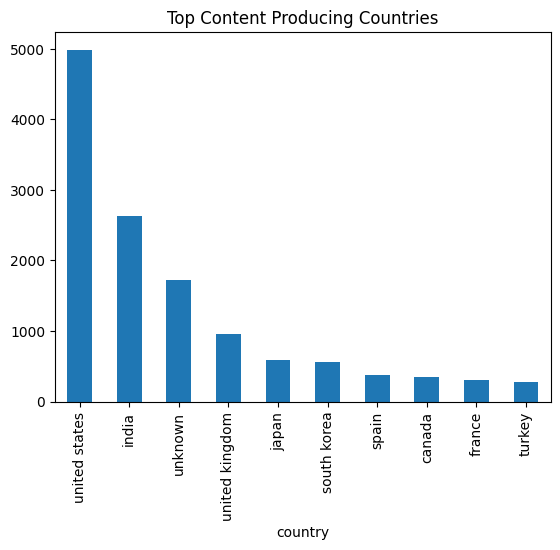

In [106]:
countries=df['country']

top_countries = countries.value_counts().head(10)

top_countries.plot(kind='bar', title='Top Content Producing Countries')

# Feature Engineering

In [107]:
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

In [108]:
def length_category(row):

    if row['type'] == 'Movie':
        if row['duration_num'] < 60:
            return 'Short'
        elif row['duration_num'] < 120:
            return 'Medium'
        else:
            return 'Long'

    else:
        if row['duration_num'] == 1:
            return 'Single Season'
        else:
            return 'Multi Season'

df['content_length_category'] = df.apply(length_category, axis=1)

In [109]:
df['is_netflix_original'] = df['title'].str.contains('Netflix', case=False, na=False)

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19294 entries, 0 to 19293
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   show_id                  19294 non-null  object        
 1   type                     19294 non-null  object        
 2   title                    19294 non-null  object        
 3   director                 19294 non-null  object        
 4   cast                     19294 non-null  object        
 5   country                  19294 non-null  object        
 6   date_added               19111 non-null  datetime64[ns]
 7   release_year             19294 non-null  int64         
 8   rating                   19294 non-null  object        
 9   duration                 19294 non-null  object        
 10  genre                    19294 non-null  object        
 11  description              19294 non-null  object        
 12  duration_minutes         19294 n